# Go2 EEG 数据集预处理演示

本 Notebook 演示如何对 `data/go2_eeg_dataset.npz` 中已经切分好的 EEG 数据进行预处理。

## 1. 导入数据

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib import font_manager
import numpy as np
import pandas as pd
from scipy import signal
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

plt.style.use("seaborn-v0_8-whitegrid")

available_fonts = {font.name for font in font_manager.fontManager.ttflist}
for font_name in ["Microsoft YaHei", "SimHei", "SimSun", "Noto Sans CJK SC", "Source Han Sans SC"]:
    if font_name in available_fonts:
        plt.rcParams["font.sans-serif"] = [font_name, "DejaVu Sans"]
        break
else:
    print("未找到常见中文字体")

plt.rcParams["axes.unicode_minus"] = False


def find_project_root(start: Path) -> Path:
    """Find the repository root from either notebook directory or project root."""
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "go2_eeg_dataset.npz").exists():
            return candidate
    raise FileNotFoundError("Could not find data/go2_eeg_dataset.npz from the current working directory.")


PROJECT_ROOT = find_project_root(Path.cwd())
DATA_PATH = PROJECT_ROOT / "data" / "go2_eeg_dataset.npz"
OUTPUT_PATH = PROJECT_ROOT / "data" / "go2_eeg_preprocessed.npz"

## 2. 读取已经切分好的 EEG trails

切分好的数据集包含 180 个 trails、8 个 channels、每个trail 4990 个采样点，采样率为 1000 Hz。标签 `L`、`S`、`R` 分别表示left、straight、right。

In [3]:
dataset = np.load(DATA_PATH, allow_pickle=True)

X = dataset["eeg_feature"].astype(np.float64)
y = dataset["label"].astype(str)

sfreq = 1000
n_trials, n_channels, n_times = X.shape
duration = n_times / sfreq
time = np.arange(n_times) / sfreq

print("数据集概览")
print(f"- 试次数: {n_trials}")
print(f"- 通道数: {n_channels}")
print(f"- 每个试次采样点数: {n_times}")
print(f"- 采样率: {sfreq} Hz")
print(f"- 单试次时长: {duration:.3f} s")

print("\n标签分布")
for label, count in zip(*np.unique(y, return_counts=True)):
    print(f"- {label}: {count}")

数据集概览
- 试次数: 180
- 通道数: 8
- 每个试次采样点数: 4990
- 采样率: 1000 Hz
- 单试次时长: 4.990 s

标签分布
- L: 60
- R: 60
- S: 60


## 3. 初步检查

滤波之前先查看一个 trail 的波形，以及各通道的基本统计量。可以看到不同通道的幅值尺度差异明显，后续会在滤波后做按通道标准化。

各通道原始信号统计
- Ch 1: mean=168137.402, std=29569.729, min=120887.703, max=207840.969
- Ch 2: mean=90551.283, std=7380.064, min=82819.945, max=101605.203
- Ch 3: mean=86963.387, std=2656.442, min=82090.695, max=90935.945
- Ch 4: mean=133228.839, std=65851.981, min=50923.445, max=231740.344
- Ch 5: mean=96706.563, std=11801.731, min=78528.820, max=109662.703
- Ch 6: mean=175324.143, std=22660.825, min=137527.578, max=206387.094
- Ch 7: mean=193899.924, std=2416.736, min=188201.203, max=202233.594
- Ch 8: mean=50274.029, std=9565.878, min=37842.441, max=63878.445



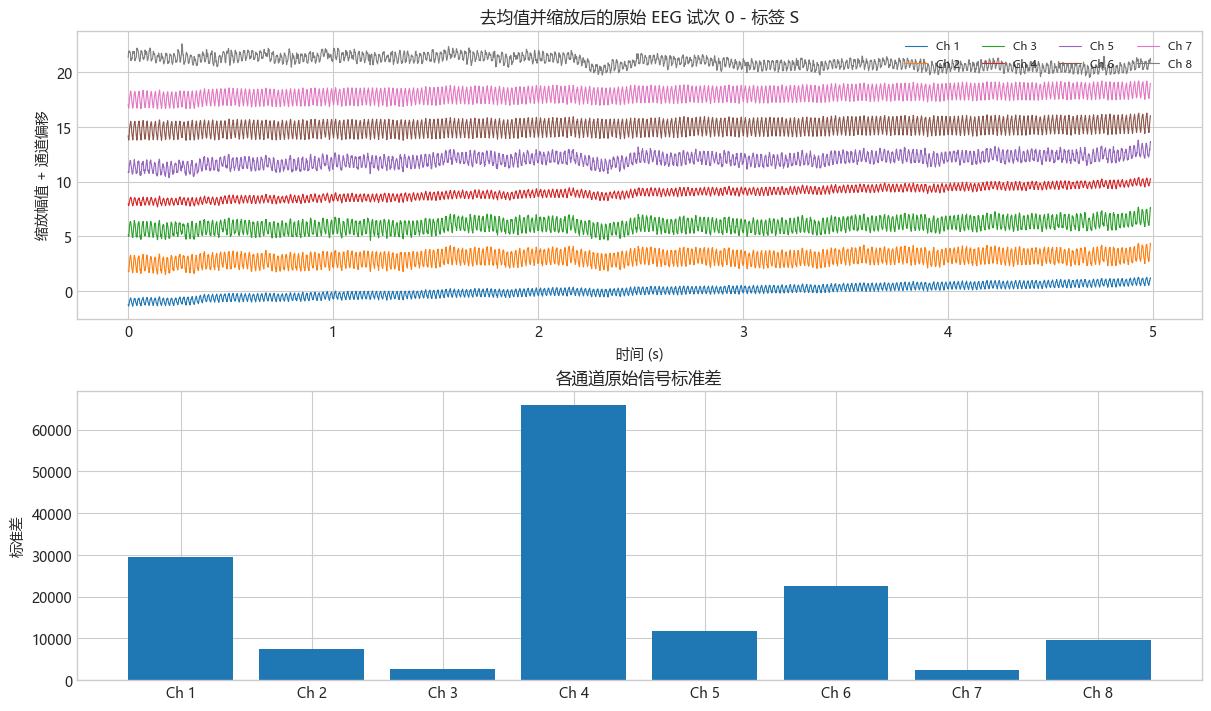

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), constrained_layout=True)

trial_idx = 0
trial_signal = X[trial_idx]

trial_centered = trial_signal - trial_signal.mean(axis=1, keepdims=True)
channel_scale = np.percentile(np.abs(trial_centered), 95, axis=1, keepdims=True)
channel_scale = np.maximum(channel_scale, 1e-8)
trial_for_plot = trial_centered / channel_scale
offsets = np.arange(n_channels) * 3.0

for ch in range(n_channels):
    axes[0].plot(time, trial_for_plot[ch] + offsets[ch], lw=0.8, label=f"Ch {ch + 1}")
axes[0].set_title(f"去均值并缩放后的原始 EEG 试次 {trial_idx} - 标签 {y[trial_idx]}")
axes[0].set_xlabel("时间 (s)")
axes[0].set_ylabel("缩放幅值 + 通道偏移")
axes[0].legend(ncol=4, fontsize=8)

channel_mean = X.mean(axis=(0, 2))
channel_std = X.std(axis=(0, 2))
channel_min = X.min(axis=(0, 2))
channel_max = X.max(axis=(0, 2))

axes[1].bar([f"Ch {i + 1}" for i in range(n_channels)], channel_std)
axes[1].set_title("各通道原始信号标准差")
axes[1].set_ylabel("标准差")

print("各通道原始信号统计")
for i in range(n_channels):
    print(
        f"- Ch {i + 1}: mean={channel_mean[i]:.3f}, std={channel_std[i]:.3f}, "
        f"min={channel_min[i]:.3f}, max={channel_max[i]:.3f}"
    )

print()


## 4. trails 质量检查

对于已经切分好的监督学习数据，简单的质量检查通常包括缺失值、无穷值，以及 peak-to-peak 幅值异常的试次。这里使用较保守的 robust z-score 阈值，真实分析中建议先人工查看被标记的试次，再决定是否删除。

质量检查结果
- 有效数值试次: 180 / 180
- 保留试次: 177 / 180
- 剔除试次: 3

各类别保留数量
- L: 58 / 60
- R: 60 / 60
- S: 59 / 60

被标记的试次
- trial 71: label=S, peak_to_peak=4058.375, robust_z=40.612, finite=True
- trial 122: label=L, peak_to_peak=4388.750, robust_z=44.720, finite=True
- trial 173: label=L, peak_to_peak=10610.625, robust_z=122.078, finite=True


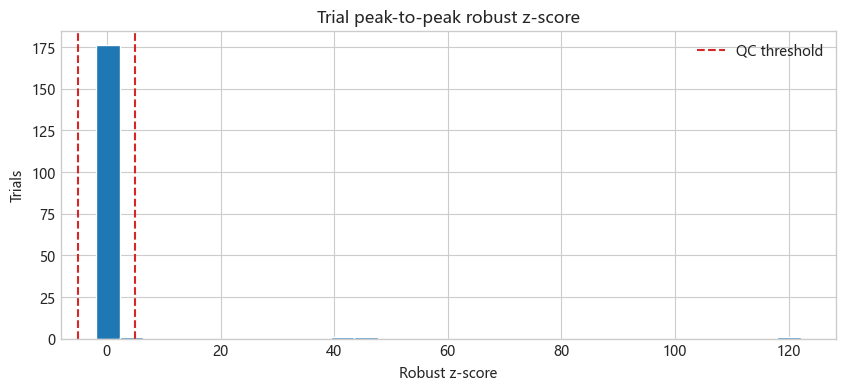

In [5]:
finite_mask = np.isfinite(X).all(axis=(1, 2))

trial_ptp = np.ptp(X, axis=2).max(axis=1)
median_ptp = np.median(trial_ptp)
mad_ptp = np.median(np.abs(trial_ptp - median_ptp))
robust_z = 0.6745 * (trial_ptp - median_ptp) / (mad_ptp + 1e-12)

artifact_mask = np.abs(robust_z) < 5
keep_mask = finite_mask & artifact_mask

print("质量检查结果")
print(f"- 有效数值试次: {finite_mask.sum()} / {len(finite_mask)}")
print(f"- 保留试次: {keep_mask.sum()} / {len(keep_mask)}")
print(f"- 剔除试次: {(~keep_mask).sum()}")

print("\n各类别保留数量")
for label in np.unique(y):
    label_mask = y == label
    print(f"- {label}: {keep_mask[label_mask].sum()} / {label_mask.sum()}")

rejected = np.flatnonzero(~keep_mask)
if len(rejected):
    print("\n被标记的试次")
    for idx in rejected[:20]:
        print(
            f"- trial {idx}: label={y[idx]}, peak_to_peak={trial_ptp[idx]:.3f}, "
            f"robust_z={robust_z[idx]:.3f}, finite={finite_mask[idx]}"
        )
else:
    print("\n没有试次被质量检查规则标记。")

plt.figure(figsize=(10, 4))
plt.hist(robust_z, bins=30, edgecolor="white")
plt.axvline(-5, color="tab:red", ls="--", label="QC threshold")
plt.axvline(5, color="tab:red", ls="--")
plt.title("Trial peak-to-peak robust z-score")
plt.xlabel("Robust z-score")
plt.ylabel("Trials")
plt.legend();

## 5. 滤波、基线校正和重采样

当前数据采样率为 1000 Hz，单个 trail 约 5 秒。这里采用适合分类示例的 pipeline ：先减去每个 trail、每个 channel 前 0.5 秒的 baseline ，再做 50 Hz 陷波滤波、1-40 Hz 带通滤波，并重采样到 250 Hz 以降低特征维度。

In [7]:
def baseline_correct(trials: np.ndarray, sfreq: int, baseline_s: float = 0.5) -> np.ndarray:
    baseline_samples = int(round(baseline_s * sfreq))
    baseline = trials[:, :, :baseline_samples].mean(axis=2, keepdims=True)
    return trials - baseline


def notch_filter(trials: np.ndarray, sfreq: int, freq: float = 50.0, quality: float = 30.0) -> np.ndarray:
    b, a = signal.iirnotch(w0=freq, Q=quality, fs=sfreq)
    return signal.filtfilt(b, a, trials, axis=2)


def bandpass_filter(trials: np.ndarray, sfreq: int, low: float = 1.0, high: float = 40.0, order: int = 4) -> np.ndarray:
    sos = signal.butter(order, [low, high], btype="bandpass", fs=sfreq, output="sos")
    return signal.sosfiltfilt(sos, trials, axis=2)


def resample_trials(trials: np.ndarray, old_sfreq: int, new_sfreq: int) -> np.ndarray:
    new_length = int(round(trials.shape[-1] * new_sfreq / old_sfreq))
    return signal.resample_poly(trials, up=new_sfreq, down=old_sfreq, axis=2)[:, :, :new_length]


target_sfreq = 250

X_qc = X[keep_mask]
y_qc = y[keep_mask]

X_processed = baseline_correct(X_qc, sfreq=sfreq, baseline_s=0.5)
X_processed = notch_filter(X_processed, sfreq=sfreq, freq=50.0)
X_processed = bandpass_filter(X_processed, sfreq=sfreq, low=1.0, high=40.0)
X_processed = resample_trials(X_processed, old_sfreq=sfreq, new_sfreq=target_sfreq)

processed_time = np.arange(X_processed.shape[-1]) / target_sfreq

X_processed.shape

(177, 8, 1248)

## 6. 对比原始信号和预处理后信号

快速检查预处理是否保留了低频 EEG 结构，同时削弱了慢漂移和高频噪声。

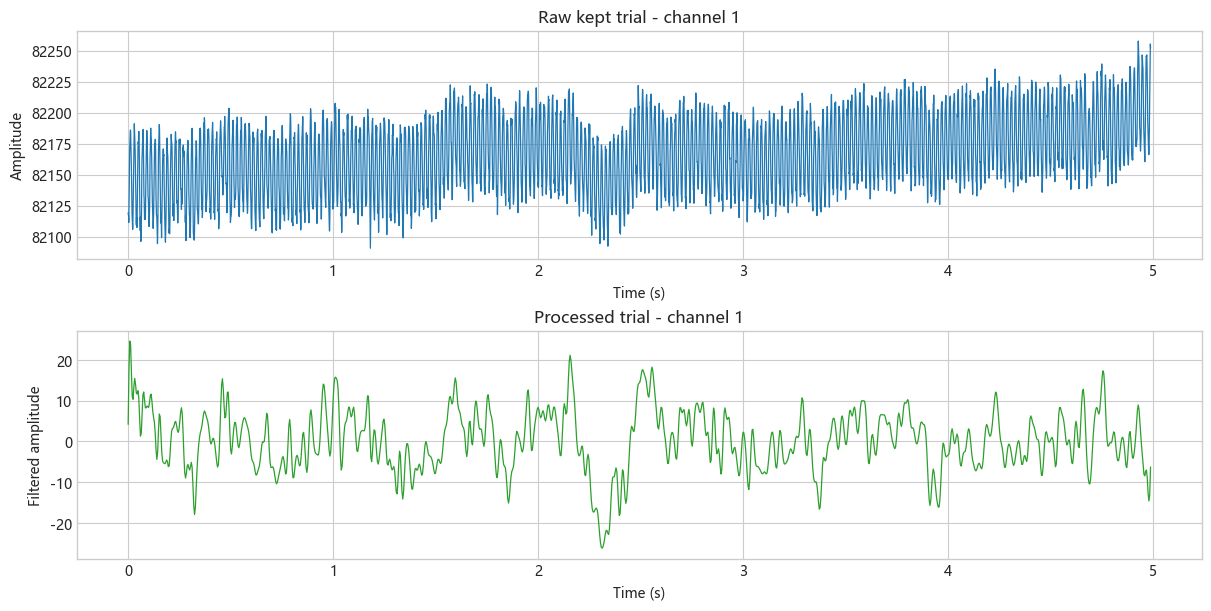

In [8]:
plot_trial = 0
plot_channel = 2

fig, axes = plt.subplots(2, 1, figsize=(12, 6), constrained_layout=True)

axes[0].plot(time, X_qc[plot_trial, plot_channel], lw=0.9)
axes[0].set_title("Raw kept trial - channel 1")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Amplitude")

axes[1].plot(processed_time, X_processed[plot_trial, plot_channel], lw=0.9, color="tab:green")
axes[1].set_title("Processed trial - channel 1")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Filtered amplitude");

## 7. 划分训练集/测试集并标准化

标准化参数只在训练集上拟合，避免把测试集信息泄漏到训练过程。这里按通道计算均值和标准差，并在 trails 与时间维度上共享同一组参数。

In [9]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_qc)

X_train, X_test, y_train, y_test = train_test_split(
    X_processed,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded,
)

channel_mean = X_train.mean(axis=(0, 2), keepdims=True)
channel_std = X_train.std(axis=(0, 2), keepdims=True) + 1e-8

X_train_z = (X_train - channel_mean) / channel_std
X_test_z = (X_test - channel_mean) / channel_std

print("Classes:", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))
print("Train:", X_train_z.shape, "Test:", X_test_z.shape)
print("Train channel mean after z-score:", np.round(X_train_z.mean(axis=(0, 2)), 4))
print("Train channel std after z-score:", np.round(X_train_z.std(axis=(0, 2)), 4))

Classes: {'L': 0, 'R': 1, 'S': 2}
Train: (141, 8, 1248) Test: (36, 8, 1248)
Train channel mean after z-score: [ 0. -0. -0. -0.  0. -0. -0.  0.]
Train channel std after z-score: [1. 1. 1. 1. 1. 1. 1. 1.]


## 8. 为传统机器学习模型准备二维特征

神经网络通常可以直接使用 `(试次, 通道, 时间点)` 形式的数据。传统机器学习模型一般需要二维特征矩阵，因此这里额外提供拉平后的版本。

In [10]:
X_train_flat = X_train_z.reshape(X_train_z.shape[0], -1)
X_test_flat = X_test_z.reshape(X_test_z.shape[0], -1)

print("特征数组形状")
print(f"- X_train_z: {X_train_z.shape}")
print(f"- X_test_z: {X_test_z.shape}")
print(f"- X_train_flat: {X_train_flat.shape}")
print(f"- X_test_flat: {X_test_flat.shape}")

特征数组形状
- X_train_z: (141, 8, 1248)
- X_test_z: (36, 8, 1248)
- X_train_flat: (141, 9984)
- X_test_flat: (36, 9984)


## 9. 保存预处理后的数据

保存的文件同时包含三维张量、二维拉平特征、标签映射、预处理参数和质量检查 mask，方便之后复现实验或检查处理流程。

In [12]:
np.savez_compressed(
    OUTPUT_PATH,
    X_train=X_train_z.astype(np.float32),
    X_test=X_test_z.astype(np.float32),
    X_train_flat=X_train_flat.astype(np.float32),
    X_test_flat=X_test_flat.astype(np.float32),
    y_train=y_train.astype(np.int64),
    y_test=y_test.astype(np.int64),
    label_classes=label_encoder.classes_,
    keep_mask=keep_mask,
    original_sfreq=sfreq,
    target_sfreq=target_sfreq,
    bandpass=np.array([1.0, 40.0]),
    notch_freq=50.0,
    channel_mean=channel_mean.astype(np.float32),
    channel_std=channel_std.astype(np.float32),
)